In [7]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


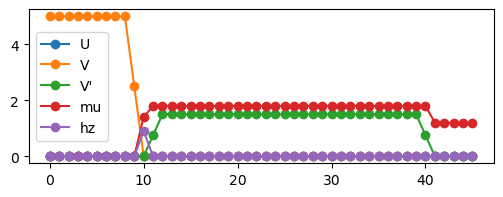

In [8]:
widthD = 10
widthF = 1
widthP = 30
widthN = 5

X, Y = widthD+widthF+widthP+widthN, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
muN = 1.2 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:widthD + widthF + widthP] = muP
mu[widthD + widthF + widthP:widthD + widthF + widthP + widthN] = muN

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 5 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD+widthP:] = 0
V_prime[widthF+widthD] = V_prime0/2
V_prime[widthF+widthD+widthP-1] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

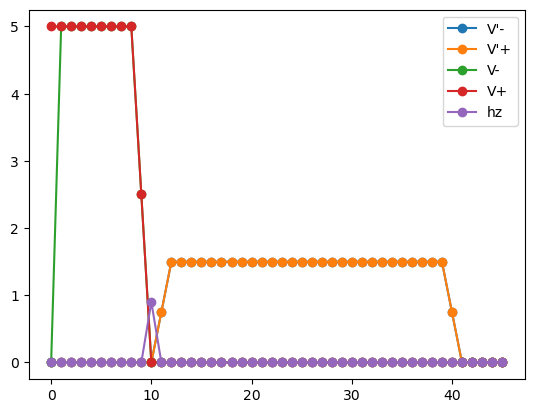

In [9]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [10]:
from scripts.utils import is_hermitian


H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.25, 0.25, -0.25, -0.25],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_kindep()))


True
True
True


In [11]:
fixed_sites = (V != 0)
fixed_syms = ["F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin"]
partial_sc(H, temperature=T,
           fixed_sites=fixed_sites,
           fixed_syms=fixed_syms,
           atol=1e-3, rtol=1e-1, maxiter=100, 
           verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.00400213267568416
Relative error: 4002132675.68416
Average old: 0j
Average: (0.00011918653930951646+0j)
F_xplus:
Absolute error: 0.006054130065474596
Relative error: 6054130065.474595
Average old: (0.05+0j)
Average: (0.05013320925252397+0j)
F_xmin:
Absolute error: 0.0016370946713569598
Relative error: 1637094671.3569598
Average old: (0.05555555555555556+0j)
Average: (0.05548131010469455+0j)
F_yplus:
Absolute error: 0.022162857306635805
Relative error: 22162857306.635807
Average old: (-0.05434782608695652+0j)
Average: (-0.054807999885877735+3.4586160675929305e-05j)
F_ymin:
Absolute error: 0.022162857306635805
Relative error: 22162857306.635807
Average old: (-0.05434782608695652+0j)
Average: (-0.054807999885877735-3.4586160675929305e-05j)
Fuu_xplus:
Absolute error: 0.23274811591185174
Relative error: 40185899792.29337
Average old: (0.06666666666666667+0j)
Average: (0.041117976062712204+0j)
Fuu_xmin:
Absolute error: 0.23104892140171002
Relative error: 37541414188.105

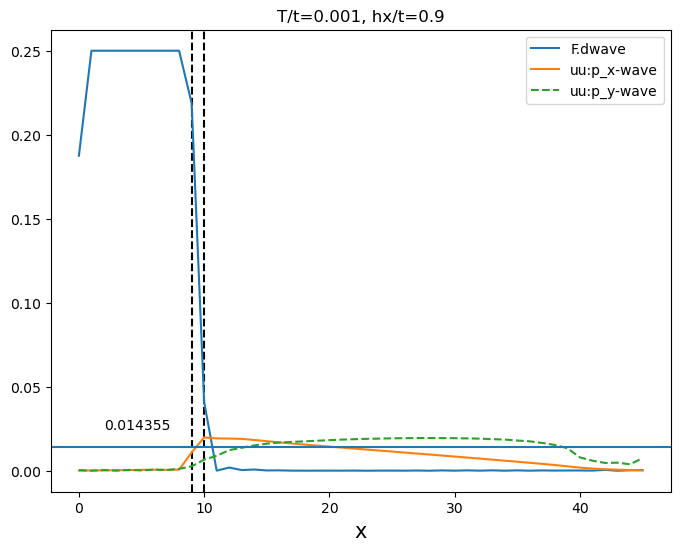

In [13]:
x = np.arange(0, widthD + widthF + widthP+ widthN)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(widthD-1, color='black', linestyle='--')
axs.axvline(widthD+widthF-1, color='black', linestyle='--')
# axs.plot(x, np.abs(H.F0), label="onsite")
axs.plot(x, np.abs(F.dwave), label="F.dwave")
# axs.plot(x, np.abs(F.swave), label="F.swave")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.axhline(np.abs(Fuu.px)[20])
axs.text(2, (np.abs(Fuu.px))[20]+0.01, f"{(np.abs(Fuu.px))[20]:.6f}")
axs.legend()
plt.show()

In [198]:
print(Fuu.px[25])
print(Fuu.py[25])


(0.05670848772930466-1.3197657650446372e-07j)
(5.707552046670724e-08+0.035805035324164805j)


In [191]:
# energies = np.linspace(-3,3,1000) 
# dos_values = H.dos(energies, eta=0.005)

# plt.figure(figsize=(5,5))
# plt.plot(energies, dos_values)
# plt.ylim(0, None)
# plt.xlim(-3,3)
# plt.xlabel(r'Energy ($E/t$)', fontsize=16)
# plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.show()

In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.110, 0.300 + 1e-12, 0.001),
])  # 210 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.11, 0.30 + 1e-12, 0.01),
    np.arange(0.301, 0.450 + 1e-12, 0.001),
    np.arange(0.460, 0.500 + 1e-12, 0.01),
])  # 194 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.35 + 1e-12, 0.01),
    np.arange(0.355, 0.450 + 1e-12, 0.005),
    np.arange(0.451, 0.550 + 1e-12, 0.001),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
])  # 174 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

print(len(temps))



184


In [205]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

print(len(temps) * len(dwave_arr))

2576
